In [86]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [87]:
results_folder = "../results/TimeSeries/3D"
create_folder(results_folder)

In [ ]:
#process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [ ]:
L_lst   = [128, 256, 512]
DIM = 3
NT  = 3000
K   = 1.0e-06

NC_list  = [2,4 8]
#RHO_list = [round(1/nc, 2) for nc in NC_list]
RHO_list = [0.125]
for L in L_lst:
    compute_means_for_folder(L, DIM, NT, K, NC_list, RHO_list)

[OK] Salvo: ../Data/bond_percolation/num_colors_8/dim_3/L_128/NT_constant/NT_3000/k_1.0e-06/rho_1.2500e-01/all_data_bundle.json
[OK] Salvo: ../Data/bond_percolation/num_colors_8/dim_3/L_256/NT_constant/NT_3000/k_1.0e-06/rho_1.2500e-01/all_data_bundle.json
[OK] Salvo: ../Data/bond_percolation/num_colors_8/dim_3/L_512/NT_constant/NT_3000/k_1.0e-06/rho_1.2500e-01/all_data_bundle.json


In [93]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
6293,128,3000,0.000001,2,0.008523,1.0,0.5,2,700,0.692514,0.000886,134.052857,0.051446,7.032390e+05,1616.481873
6292,128,3000,0.000001,2,0.008523,1.0,0.5,1,700,0.697425,0.000877,134.040000,0.051641,7.009120e+05,1716.171344
3578,512,3000,0.000001,8,0.009970,1.0,0.1,7,50,0.257348,0.000077,1780.700000,3.611574,6.031849e+06,10270.214830
3577,512,3000,0.000001,8,0.009970,1.0,0.1,6,50,0.257250,0.000075,1781.540000,3.889831,6.030882e+06,10312.063840
3576,512,3000,0.000001,8,0.009970,1.0,0.1,5,50,0.256702,0.000081,1778.040000,3.623839,6.030314e+06,10282.289067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6922,512,3000,0.000001,2,0.500000,1.0,0.1,1,50,0.250217,0.000060,2979.000000,24.619372,9.876859e+06,65973.800474
6923,512,3000,0.000001,2,0.500000,1.0,0.1,2,50,0.250255,0.000057,3072.520000,21.069743,9.885095e+06,64681.009093
6360,128,3000,0.000001,2,0.500000,1.0,0.1,1,501,0.556967,0.000928,144.389222,0.165329,8.973682e+05,2663.674854
6362,128,3000,0.000001,2,0.500000,1.0,1.0,1,1,0.495806,0.010437,145.000000,0.000000,9.585250e+05,0.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 512
nc = 8
orders = [i for i in range(1, nc+1)]
P0 = 0.1
p0 = 1.0
WINDOW = 5  # nº de pontos na janela (ajuste conforme quiser)

#plt.figure(figsize=(10,4))

for order in orders:
    df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
    df_f = df_f.sort_values("rho")  # garante ordem crescente no eixo x

    x = df_f["rho"].to_numpy()
    y = df_f["p_mean"].to_numpy()

    # média móvel centrada
    y_ma = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .mean()
        .to_numpy()
    )

    # desvio padrão na janela e erro padrão da média
    y_std = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .std()
        .to_numpy()
    )
    y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))  # aproxima

    # série original (mais clarinha) + média móvel
    plt.plot(x, y, alpha=0.35)
    plt.plot(x, y_ma, linewidth=2, label=f"i = {order}")

    # faixa opcional de incerteza (comente se não quiser)
    plt.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

plt.legend()
plt.xlabel(r"$\rho$")
#plt.axhline(y=0.24881182, xmin=0, xmax=0.5)
plt.ylabel(r"$p_c^{\infty}$")
plt.xlim([0, 1/nc ])
plt.tight_layout()
plt.show()

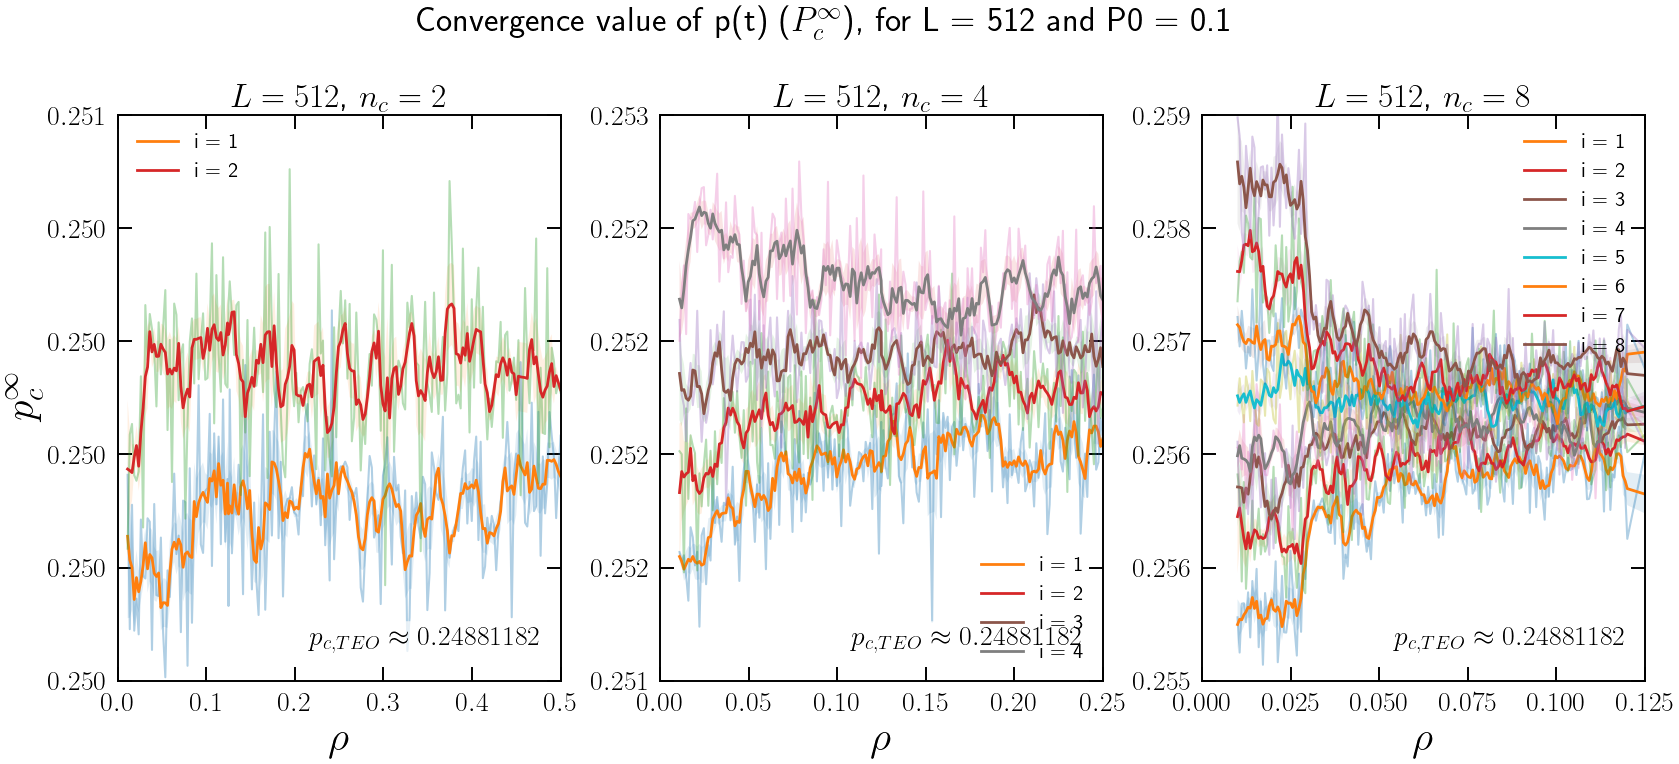

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 512
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
ylims = [(0.2500, 0.2505), (0.2514, 0.2526) ,(0.2550, 0.2585)]

fig, axes = plt.subplots(1, 3, figsize=(17, 8), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4
for ax, nc, ylim in zip(axes, NC_LIST, ylims):
    orders = [i for i in range(1, nc+1)]

    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["p_mean"].to_numpy()

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2, label=f"i = {order}")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

    # limites e ticks específicos por painel
    ax.set_ylim(ylim)
    yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$L = {L}$, $n_c = {nc}$")
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    ax.text(
        0.95, 0.05,               # (x,y) no sistema [0..1] do eixo
        r"$p_{c,TEO} \approx 0.24881182$",
        transform=ax.transAxes, # usa coords do eixo
        ha="right", va="bottom",
        fontsize=20,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)  # opcional
    )
    #ax.set_ylim(0.250, 0.259)
axes[0].set_ylabel(r"$p_c^{\infty}$",fontsize=30)
fig.suptitle(fr"Convergence value of p(t) ($P_c^\infty$), for L = {L} and P0 = {P0}", fontsize=25, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
#plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()


/tmp/ipykernel_23571/2831302362.py:108: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.82)


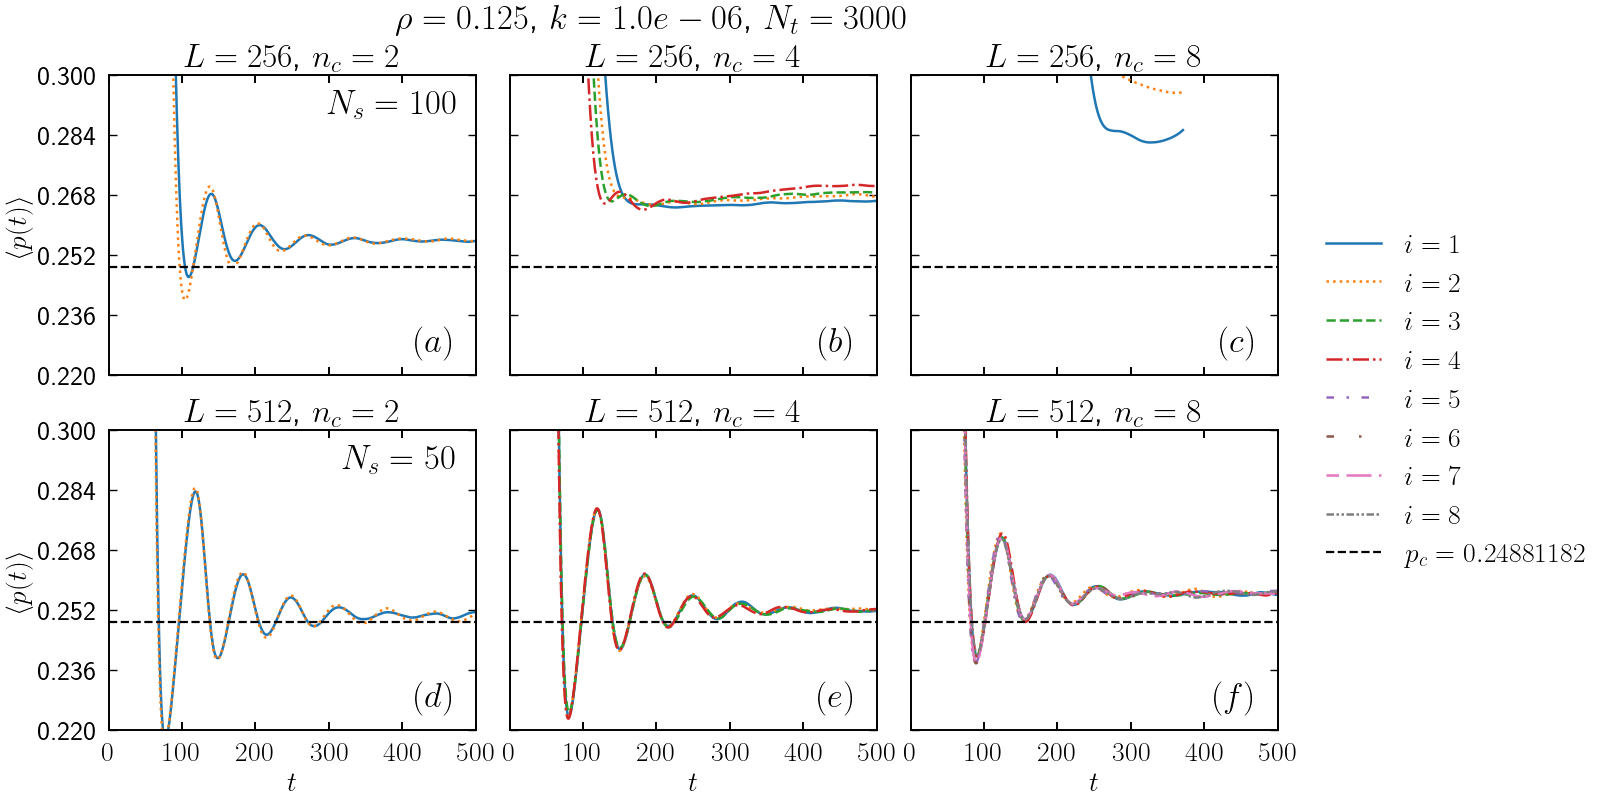

In [89]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib.ticker import LinearLocator, AutoMinorLocator, FormatStrFormatter

def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional

nc_list = [2, 4, 8]
k = 1.0e-06
NT = 3000
p0 = 1.0
L_list = [256, 512]
pc_ref = 0.24881182

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)

labels_fig = ["$(a)$", "$(b)$", "$(c)$", "$(d)$", "$(e)$", "$(f)$"]
labels_Ns = [r"$N_s = 100$", "$N_s = 50$"]
legend_lines = {}  # guarda um Line2D por índice i

for i_row, L in enumerate(L_list):
    for j_col, nc_val in enumerate(nc_list):
        ax = axes[i_row, j_col]
        rho = 0.125
        filename = (
            f"../Data/bond_percolation/num_colors_{nc_val}/dim_3/"
            f"L_{L}/NT_constant/NT_3000/k_1.0e-06/rho_{rho:.4e}/all_data_bundle.json"
        )

        try:
            bundle, df = read_all_data_bundle(filename, as_dataframe=True)
        except Exception:
            ax.text(0.5, 0.5, "arquivo não encontrado\nou erro ao ler",
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        if df.empty:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center',
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        orders = np.sort(df['order'].unique())
        x_max = 0.0

        for idx_ord, ord_val in enumerate(orders, start=1):
            df_f = df[df['order'] == ord_val]
            if df_f.empty:
                continue

            line, = ax.plot(df_f['t'], df_f['pt'],
                            lw=1.8,
                            ls=ls[idx_ord-1],  # <- corrige o off-by-one
                            label=fr'$i={idx_ord}$')

            # guarde o primeiro artista de cada i para a legenda global
            if idx_ord not in legend_lines:
                legend_lines[idx_ord] = line

            if len(df_f['t']) and np.nanmax(df_f['t']) > x_max:
                x_max = float(np.nanmax(df_f['t']))

        ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
        if x_max > 0:
            ax.set_xlim(0, int(x_max))
        ax.axhline(y=pc_ref, ls='--', lw=1.6, color='k')

        if j_col == 0:
            ax.set_ylabel(r'$\langle p(t) \rangle$')
            ax.text(0.95, 0.85, labels_Ns[i_row],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
        
        if i_row == len(L_list) - 1:
            ax.set_xlabel(r'$t$')

        if i_row != 0:
            ax.set_ylim(0.22, 0.30)

        ax.set_xlim(0, 500)

        aplicar_ticks(ax, n_xticks=6, n_yticks=6)
        if i_row != len(L_list) - 1:        # esconde nas linhas de cima
            ax.tick_params(axis='x', which='both', labelbottom=False)
        else:                                # mostra só na última linha
            ax.tick_params(axis='x', which='both', labelbottom=True)
        
        if j_col != 0:
            ax.tick_params(axis='y', which='both', labelleft=False)

        # Adiciona os labels nos cantos inferiores direitos
        ax.text(0.95, 0.05, labels_fig[i_row * len(nc_list) + j_col],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
         
# ===== legenda global usando os próprios artistas =====
fig.subplots_adjust(right=0.82)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)
labels.append(fr'$p_c={pc_ref}$')

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False)
fig.suptitle(fr"$\rho={rho}$, $k = {k:.1e}$, $N_t = {NT}$", fontsize=25, fontweight='bold')  # Adds a title to the entire figure

plt.savefig(results_folder + "/TimeSeries_L_and_nc_multi_samples.pdf")
plt.show()


/tmp/ipykernel_23571/1356419263.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.82)


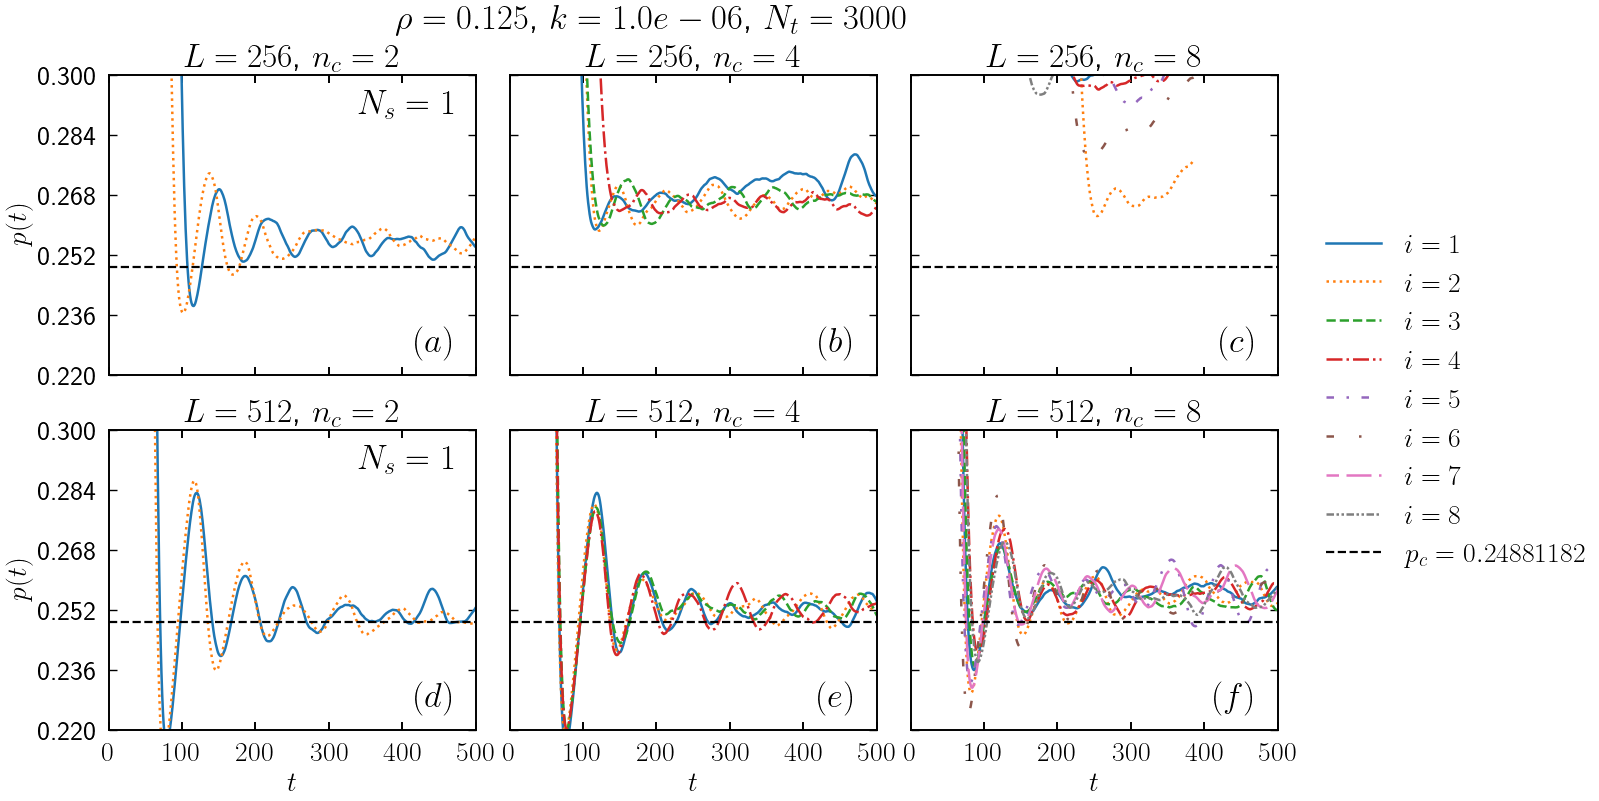

In [90]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random
import json

from matplotlib.ticker import LinearLocator, AutoMinorLocator, FormatStrFormatter

def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # Coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional


# Parâmetros
nc_list = [2, 4, 8]
L_list = [256, 512]
RHO = 0.125
labels_Ns = [r"$N_s = 1$", "$N_s = 1$"]

# Estilos de linha para as curvas
ls = ['solid', 'dotted', 'dashed', 'dashdot', 
      (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), 
      (5, (10, 3)), 
      (0, (3, 1, 1, 1, 1, 1))]  # Máximo de 8 estilos

# Criação dos subplots
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)

labels_fig = ["$(a)$", "$(b)$", "$(c)$", "$(d)$", "$(e)$", "$(f)$"]
legend_lines = {}  # Usando um dicionário para garantir uma linha única por label

for i_row, L in enumerate(L_list):
    for j_col, nc_val in enumerate(nc_list):
        ax = axes[i_row, j_col]
        folder = f"/home/light/Documents/self_organization_percolation/Data/bond_percolation/num_colors_{nc_val}/dim_3/L_{L}/NT_constant/NT_3000/k_1.0e-06/rho_{RHO:.4e}/data"
        file_path = select_random_json(folder)

        if file_path is None:
            ax.text(0.5, 0.5, "arquivo não encontrado\nou erro ao ler", ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        # Carrega os dados do arquivo JSON
        df = read_orders_one_file_fix(file_path)

        if not df or 'results' not in df:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        # Verifica se 'results' é um dicionário e acessa as chaves
        if isinstance(df['results'], dict):
            orders = np.sort(list(df['results'].keys()))  # Converte as chaves para lista e ordena
        else:
            print("Estrutura de 'results' não é um dicionário")
            continue

        x_max = 0.0
        # Plotando as ordens de percolação com diferentes estilos de linha
        for idx_ord, ord_key in enumerate(orders[:8], start=1):  # Limita a 8 ordens
            order_data = df['results'].get(ord_key, {}).get('data', {})
            if not order_data:
                continue
            t = order_data.get('time', [])
            pt = order_data.get('pt', [])

            if t and pt:
                # Garantir que apenas o primeiro artista de cada `i` seja adicionado à legenda
                line, = ax.plot(t, pt, label=f'i = {idx_ord}', lw=1.8, ls=ls[idx_ord-1])
                if idx_ord not in legend_lines:
                    legend_lines[idx_ord] = line  # Armazena o primeiro artista para esse `i`

                if np.nanmax(t) > x_max:
                    x_max = float(np.nanmax(t))

        ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
        if x_max > 0:
            ax.set_xlim(0, int(x_max))
        ax.axhline(y=0.24881182, ls='--', lw=1.6, color='k')

        if j_col == 0:
            ax.set_ylabel(r'$p(t)$')
            ax.text(0.95, 0.85, labels_Ns[i_row],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
        if i_row == len(L_list) - 1:
            ax.set_xlabel(r'$t$')

        if i_row != 0:
            ax.set_ylim(0.22, 0.30)

        ax.set_xlim(0, 500)

        aplicar_ticks(ax, n_xticks=6, n_yticks=6)
        if i_row != len(L_list) - 1:
            ax.tick_params(axis='x', which='both', labelbottom=False)
        else:
            ax.tick_params(axis='x', which='both', labelbottom=True)

        if j_col != 0:
            ax.tick_params(axis='y', which='both', labelleft=False)

        # Adiciona os labels nos cantos inferiores direitos
        ax.text(0.95, 0.05, labels_fig[i_row * len(nc_list) + j_col], transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

# ===== legenda global usando os próprios artistas =====
fig.subplots_adjust(right=0.82)

# Ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [f'$i={i}$' for i in sorted(legend_lines.keys())]

# Adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)
labels.append(fr'$p_c={0.24881182}$')

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

fig.suptitle(fr"$\rho={RHO}$, $k = {1.0e-06:.1e}$, $N_t = {3000}$", fontsize=25, fontweight='bold')  # Adds a title to the entire figure

plt.savefig(results_folder + "/TimeSeries_L_and_nc_single_sample.pdf")
plt.show()

TypeError: 'AxesSubplot' object is not subscriptable

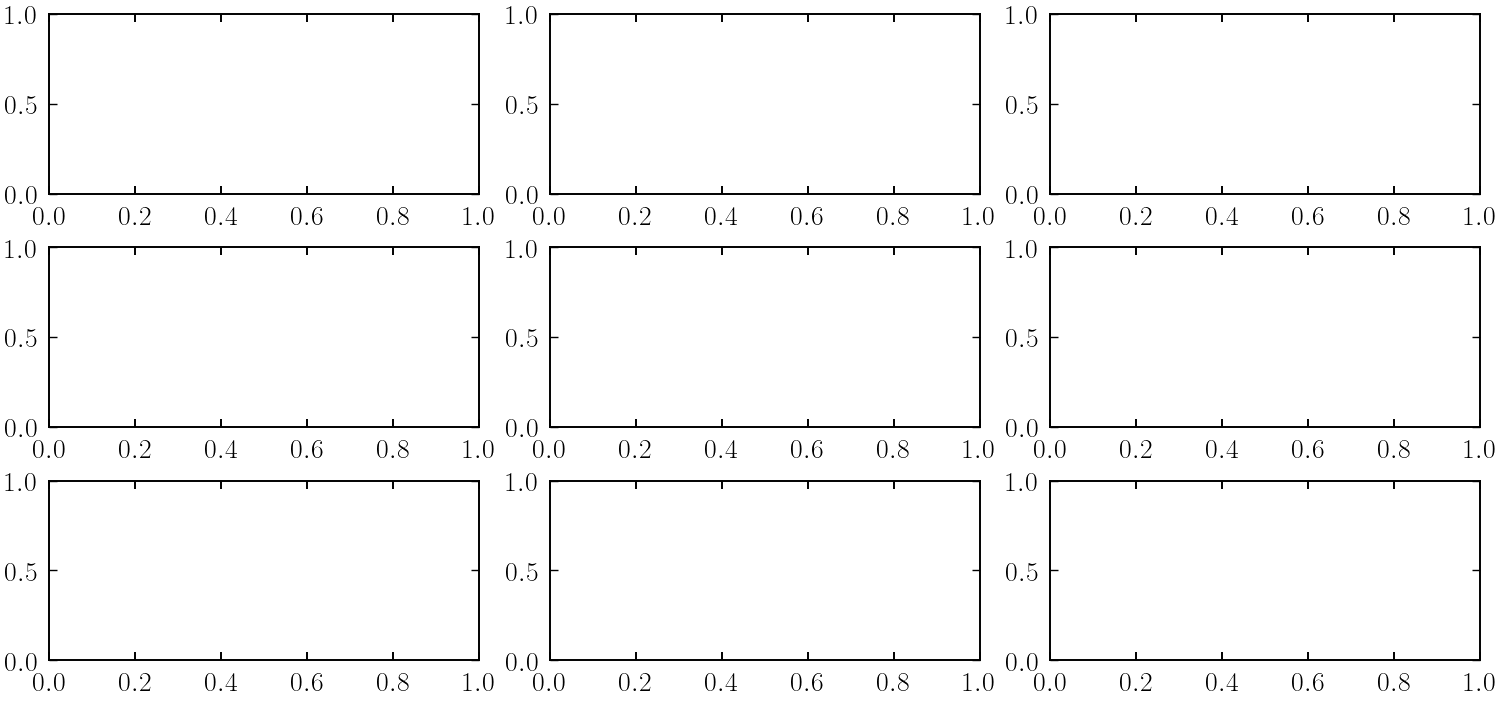

In [91]:
nc = [2,4,8]
rho = 0.5
p0 = 1.0
L_lst = [128, 256, 512]

fig, axes = plt.subplots(3, 3, figsize=(15, 7), constrained_layout=True)
count = 0
for idx, l in enumerate(L_lst):
    for axs in axes[idx,:]:
        for l in L_lst:
            filename = f"../Data/bond_percolation/num_colors_{nc[idx]}/dim_3/L_{l}/NT_constant/NT_3000/k_1.0e-06/rho_{rho:.4e}/all_data_bundle.json"
            bundle, df = read_all_data_bundle(filename, as_dataframe=True)
            orders = df['order'].unique()
            x_max = 0
            
            for idx, ord in enumerate(orders):
                df_filter = df[df['order']==ord]
                axs[idx, count].plot(df_filter['t'], df_filter['pt'],label=f'$i = {idx+1}$')
            
                if(x_max < max(df_filter['t'])):
                    x_max = max(df_filter['t'])
                
            axs[idx,count].set_title(f"$L = {l}$, $n_c = {nc}$")
            axs[idx,count].set_xlim(0, int(x_max))
            axs[idx,count].axhline(y=0.24881182,xmax=int(x_max),xmin=0, ls='--', lw='1.6', color='k' ,label=r'$p_c = 0.24881182$')
            count += 1


# for ax in axs:
#     ax.set_xlabel('$t$')
#     ax.set_ylim(0.2, 0.3)    
#     ax.legend()
#axs[0].set_ylabel('$p(t)$')
fig.suptitle(fr"Value of $p(t)$, with $N_s = {num_samples}$ samples, for $L = {L}$ and $P0 = {P0}$", fontsize=25, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
#plt.savefig(results_folder + f"/pt_series_L_{L}_with_zoom.pdf")
plt.show()

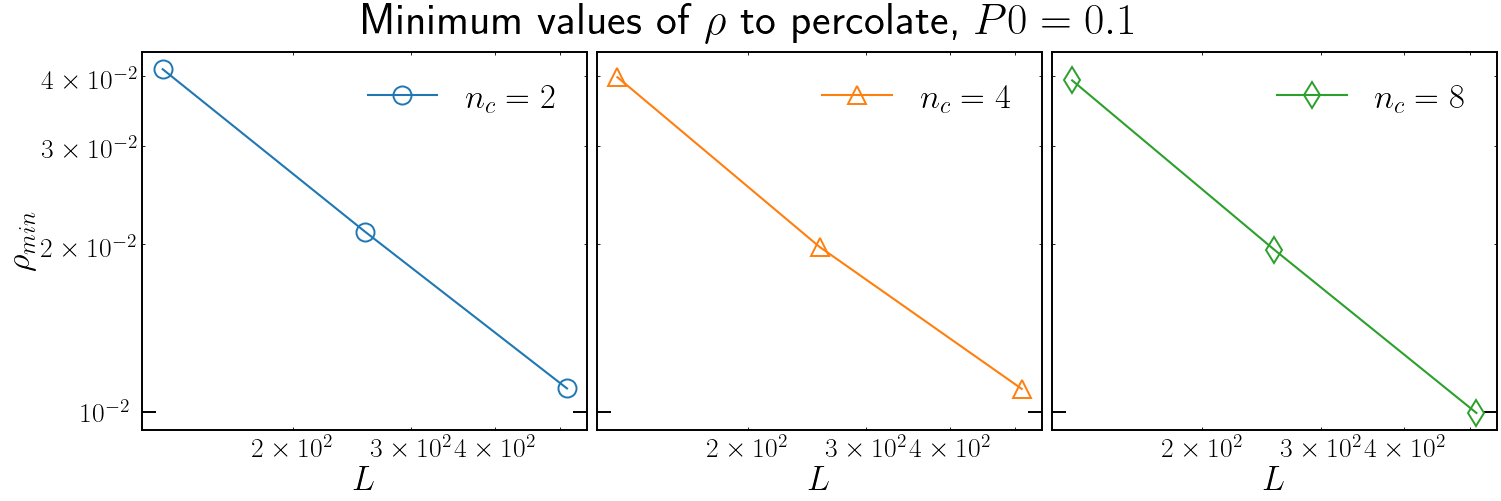

In [94]:
L = [128, 256, 512]
NC_LST = [2, 4, 8]
RHO_LST = [round(1/nc,2) for nc in NC_LST]
p0 = 1.0
P0 = 0.1
L = [128, 256, 512]
order = 1
rho_min_by_nc = {"nc":[], "L":[], "rho_min":[]}

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharex=True, sharey=True)
count = 0
for nc in NC_LST:
    for l in L:
        df_filter = df[(df["L"]==l) & (df["nc"]==nc) & (df['order']==1) & (df["P0"]==P0)]
        rho_min = df_filter['rho'].min()
        
        rho_min_by_nc['nc'].append(nc)
        rho_min_by_nc['L'].append(l)
        rho_min_by_nc['rho_min'].append(rho_min)

df__ = pd.DataFrame(data=rho_min_by_nc)

markers = ["o", "^", "d"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
count =0
ms = 13
fontsize_labels = 25
fontsize_legend = 25
thickness_axes = 1.4

for nc, ax in zip(NC_LST, axs.flatten()):
    df_ = df__[df__["nc"] == nc]
    ax.plot(df_['L'], df_["rho_min"], marker=markers[count],ms = ms, mew=thickness_axes,
            color=colors[count], label=f'$n_c = {nc}$')
    ax.set_xlabel("$L$", fontsize = fontsize_labels)
    ax.legend(fontsize = fontsize_legend)
    count += 1
    
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    ax.set_xscale("log")
    ax.set_yscale("log")
fig.suptitle(fr"Minimum values of $\rho$ to percolate, $P0 = {P0}$", fontsize=32, fontweight='bold') # Adds a title to the entire figure
axs[0].set_ylabel(r'$\rho_{min}$', fontsize = fontsize_labels)
plt.show()
#print(rho_min_by_nc)